In [1]:
import math
import random as rn
import numpy as np
from copy import deepcopy
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# set up matplotlib
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion()

In [ ]:
episode_rewards = []
loss_list = []
epsi_list = []

def plot_durations(show_result=False):
    fig, ax1 = plt.subplots()
    # plt.figure(1)
    durations_t = torch.tensor(episode_rewards, dtype=torch.float)
    epsi_t = torch.tensor(epsi_list, dtype=torch.float)
    # if show_result:
    #     fig.title('Result')
    # else:
        # fig.clf()
        # fig.title('Training...')
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Reward')
    ax1.plot(durations_t.numpy())

    # Take 100 episode averages and plot them too
    window_size = 20
    if len(durations_t) >= window_size:
        means = durations_t.unfold(0, window_size, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(window_size - 1), means))
        ax1.plot(means.numpy())

    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('epislon', color=color)  # we already handled the x-label with ax1
    ax2.plot(epsi_t, color=color)
    ax2.tick_params(axis='y', labelcolor=color)

    fig.tight_layout()  # otherwise the right y-label is slightly clipped

    plt.pause(0.001)  # pause a bit so that plots are updated
    if is_ipython:
        if not show_result:
            display.display(plt.gcf())
            display.clear_output(wait=True)
        else:
            display.display(plt.gcf())

In [3]:
%load_ext autoreload
%autoreload 2

from grid_vis_new import run_grid
from board_cell_classes import DQN, ReplayMemory, DLGrid

Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))

class DLGridNotebook(DLGrid):
    def reset(self):
        episode_rewards.append(int(self.score))
        epsi_list.append(self.EPS_CURRENT)
        plot_durations()
        super().reset()

<Figure size 640x480 with 0 Axes>

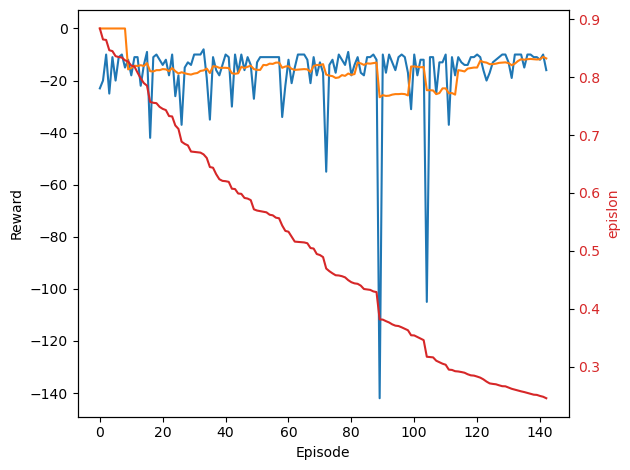

<Figure size 640x480 with 0 Axes>

In [ ]:
grid =  DLGridNotebook((12, 12))
grid.run_n_episodes(n=600, vis=True)

print('Complete')
plot_durations(show_result=True)
plt.ioff()
plt.show()